<a href="https://colab.research.google.com/github/droyktton/ICNPG/blob/master/Clases/Colaboratory/ejemplocugraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Thu May 20 02:30:06 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 465.19.01    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   49C    P8    10W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

#Setup:
Set up script installs
1. Install most recent Miniconda release compatible with Google Colab's Python install  (3.7.10)
1. removes incompatible files
1. Install RAPIDS' current stable version of its libraries, including:
  1. cuDF
  1. cuML
  1. cuGraph
  1. cuSpatial
  1. cuSignal
  1. xgboost
1. Set necessary environment variables
1. Copy RAPIDS .so files into current working directory, a workaround for conda/colab interactions


Atenti, lo siguiente demora unos cuantos 10 minutos... y te quedas con poco disco, pero algo se puede hacer en colabs

In [ ]:
# Install RAPIDS
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!bash rapidsai-csp-utils/colab/rapids-colab.sh stable

import sys, os, shutil

sys.path.append('/usr/local/lib/python3.7/site-packages/')
os.environ['NUMBAPRO_NVVM'] = '/usr/local/cuda/nvvm/lib64/libnvvm.so'
os.environ['NUMBAPRO_LIBDEVICE'] = '/usr/local/cuda/nvvm/libdevice/'
os.environ["CONDA_PREFIX"] = "/usr/local"
for so in ['cudf', 'rmm', 'nccl', 'cuml', 'cugraph', 'xgboost', 'cuspatial']:
  fn = 'lib'+so+'.so'
  source_fn = '/usr/local/lib/'+fn
  dest_fn = '/usr/lib/'+fn
  if os.path.exists(source_fn):
    print(f'Copying {source_fn} to {dest_fn}')
    shutil.copyfile(source_fn, dest_fn)
# fix for BlazingSQL import issue
# ImportError: /usr/lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.26' not found (required by /usr/local/lib/python3.7/site-packages/../../libblazingsql-engine.so)
if not os.path.exists('/usr/lib64'):
    os.makedirs('/usr/lib64')
for so_file in os.listdir('/usr/local/lib'):
  if 'libstdc' in so_file:
    shutil.copyfile('/usr/local/lib/'+so_file, '/usr/lib64/'+so_file)
    shutil.copyfile('/usr/local/lib/'+so_file, '/usr/lib/x86_64-linux-gnu/'+so_file)

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 238 (delta 36), reused 11 (delta 5), pack-reused 171
Receiving objects: 100% (238/238), 73.89 KiB | 12.31 MiB/s, done.
Resolving deltas: 100% (98/98), done.
PLEASE READ
********************************************************************************************************
Changes:
1. IMPORTANT SCRIPT CHANGES: Colab has updated to Python 3.7, and now runs our STABLE and NIGHTLY versions (0.19 and 0.20)!  PLEASE update your older install script code as follows:
	!bash rapidsai-csp-utils/colab/rapids-colab.sh 0.19

	import sys, os, shutil

	sys.path.append('/usr/local/lib/python3.7/site-packages/')
	os.environ['NUMBAPRO_NVVM'] = '/usr/local/cuda/nvvm/lib64/libnvvm.so'
	os.environ['NUMBAPRO_LIBDEVICE'] = '/usr/local/cuda/nvvm/libdevice/'
	os.environ['CONDA_PREFIX'] = '/usr/local'
	for so in ['cudf', 'rmm',

# CUGRAPH, CUDF, CUPY, todo en GPU !!!

Este es un ejemplito de como leer un csv con los edges de un grafo, visualizarlo, y realizar operaciones en la gpu.

Esta biblioteca es para ver el grafo nomas...

In [ ]:
pip install graphviz

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Visualización del grafo y de la matriz de adyacencia

matriz de adjacencia:
 [[1. 1. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 1. 0. 0. 0.]
 [1. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]
matriz de adjacencia a la 4:
 [[19. 16.  9. 10. 16.  3.  0.  0.  0.]
 [16. 18.  4. 14. 10.  1.  0.  0.  0.]
 [ 9.  4. 10.  1. 13.  5.  0.  0.  0.]
 [10. 14.  1. 14.  4.  0.  0.  0.  0.]
 [16. 10. 13.  4. 19.  6.  0.  0.  0.]
 [ 3.  1.  5.  0.  6.  3.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1.]]
zeros de la matriz:  18
zeros de la matriz^4:  37


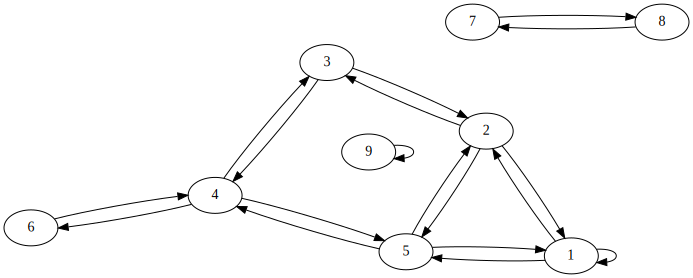

In [ ]:
#########################################
# Echemosle un vistazo al grafo usando graphiz

import cugraph
import cudf
import cupy as cp
from graphviz import Digraph

# read data into a cuDF DataFrame using read_csv
#gdf = cudf.read_csv("graph_data.csv", names=["src", "dst"], dtype=["int32", "int32"])
gdf = cudf.read_csv("/content/drive/MyDrive/Classroom/Introducción al Cálculo Numérico en Procesadores Gráficos Materia Optativa/Codigos_de_las_Clases/common/graph_data.csv")
dot = Digraph(comment='INPG2021',engine='sfdp')

gpa=gdf.to_pandas()

madj=cp.zeros((9,9))

for a, b in gpa.itertuples(index=False):
    dot.edge(str(a),str(b), constraint='false')
    madj[a-1,b-1]=1
    #print(a, b)


print("matriz de adjacencia:\n",madj)

madj8=cp.linalg.matrix_power(madj,4)
print("matriz de adjacencia a la 4:\n",madj8)

print("zeros de la matriz: ",cp.flatnonzero(madj).size)
print("zeros de la matriz^4: ",cp.flatnonzero(madj8).size)

dot

##  CUGRAPH para obtener propiedades del grafo

In [ ]:
pip install cffi==1.14.5

  Using cached cffi-1.14.5-cp37-cp37m-manylinux1_x86_64.whl (402 kB)


In [ ]:
import cugraph
import cudf

# read data into a cuDF DataFrame using read_csv
#gdf = cudf.read_csv("graph_data.csv", names=["src", "dst"], dtype=["int32", "int32"])
gdf = cudf.read_csv("/content/drive/MyDrive/Classroom/Introducción al Cálculo Numérico en Procesadores Gráficos Materia Optativa/Codigos_de_las_Clases/common/graph_data.csv")


# We now have data as edge pairs
# create a Graph using the source (src) and destination (dst) vertex pairs
G = cugraph.Graph()
G.from_cudf_edgelist(gdf, source='src', destination='dst')

print("\n\n")



######################################
#https://es.wikipedia.org/wiki/PageRank
#
# PR(A) = (1-d)+d Sum_{i=1}^n PR(i)/C(i)
#
# A es el PageRank de la página A.
# d es un factor de amortiguación que tiene un valor entre 0 y 1.
# PR(i)son los valores de PageRank que tienen cada una de las páginas i que enlazan a A.
# C(i) es el número total de enlaces salientes de la página i (sean o no hacia A).

# Let's now get the PageRank score of each vertex by calling cugraph.pagerank
df_page = cugraph.pagerank(G)

# Let's look at the PageRank Score (only do this on small graphs)
for i in range(len(df_page)):
	print("vertex " + str(df_page['vertex'].iloc[i]) +
		" PageRank is " + str(df_page['pagerank'].iloc[i]))

print("\n\n")

#####################################
#https://en.wikipedia.org/wiki/Component_(graph_theory)

# Call cugraph.weakly_connected_components on the dataframe
df_cc = cugraph.weakly_connected_components(G)

# Use groupby on the 'labels' column of the WCC output to get the counts of each connected component label
label_gby = df_cc.groupby('labels')
label_count = label_gby.count()

print("Total number of components found : ", len(label_count))

# Call nlargest on the groupby result to get the row where the component count is the largest
largest_component = label_count.nlargest(n = 1, columns = 'vertex')
print("Size of the largest component is found to be : ", largest_component['vertex'].iloc[0])
smallest_component = label_count.nsmallest(n = 1, columns = 'vertex')
print("Size of the smallest component is found to be : ", smallest_component['vertex'].iloc[0])


#df_cc.head(20)

print("\n\n")

#############################################################
# https://en.wikipedia.org/wiki/Shortest_path_problem
# Call cugraph.sssp to get the distances from vertex 1:
# pesos (necesarios para algunas cosas nomas)

df_ssp = cugraph.sssp(G, 1)

print("no todos los caminos conducen al nodo 1, y estos son los minimos:")

# Print the paths
for index, row in df_ssp.to_pandas().iterrows():
    v = int(row['vertex'])
    p = cugraph.utils.get_traversed_path_list(df, v)
    print(v, ': ', p)

print("\n\n")

##############################################################
# Call cugraph.pagerank to get the pagerank scores
cu_count = cugraph.triangles(G)
print("numero de triangulos: ", cu_count)

print("\n\n")





vertex 1 PageRank is 0.12384827
vertex 2 PageRank is 0.12706584
vertex 4 PageRank is 0.13981377
vertex 5 PageRank is 0.12737396
vertex 3 PageRank is 0.092283614
vertex 6 PageRank is 0.056281246
vertex 7 PageRank is 0.11111111
vertex 8 PageRank is 0.11111111
vertex 9 PageRank is 0.11111111



Total number of components found :  3
Size of the largest component is found to be :  6
Size of the smallest component is found to be :  1





Exception: ignored

## CUDF como pandas, pero en GPU

In [ ]:
import cudf
import io, requests

# download CSV file from GitHub
url="https://github.com/plotly/datasets/raw/master/tips.csv"
content = requests.get(url).content.decode('utf-8')

# read CSV from memory
tips_df = cudf.read_csv(io.StringIO(content))
tips_df['tip_percentage'] = tips_df['tip']/tips_df['total_bill']*100

# display average tip by dining party size
print(tips_df.groupby('size').tip_percentage.mean())

size
6    15.622920
1    21.729202
4    14.594901
3    15.215685
2    16.571919
5    14.149549
Name: tip_percentage, dtype: float64


# Next Steps #

For an overview of how you can access and work with your own datasets in Colab, check out [this guide](https://towardsdatascience.com/3-ways-to-load-csv-files-into-colab-7c14fcbdcb92).

For more RAPIDS examples, check out our RAPIDS notebooks repos:
1. https://github.com/rapidsai/notebooks
2. https://github.com/rapidsai/notebooks-contrib